# Discriminating Oncology Drug-Response Phenotypes from Pharmacodynamic Biomarkers with PROC HPCANDISC

## Executive Summary

In a Phase II oncology trial, patients fall into distinct response phenotypes (non-responder, partial, complete) that are rarely separable on any single biomarker. This notebook uses high-performance canonical discriminant analysis (PROC HPCANDISC) to find the linear combinations of five pharmacodynamic biomarkers that maximally separate the three response groups, quantifies how strongly each axis discriminates, and scores every patient onto the canonical space for downstream visualization and triage.

## Data Sources

**Synthetic dataset: `work.pkpd`** — 99 simulated Phase II oncology patients, one row per patient, generated inline with `call streaminit(20260531)` and `rand("Normal", ...)`. Patients are assigned in round-robin order to one of three drug-response phenotypes (33 per group), and five pharmacodynamic biomarkers are drawn from group-specific means plus Gaussian noise so the groups overlap realistically rather than separating perfectly.

| Variable | Type | Description |
|----------|------|-------------|
| `PatientID` | Num | Unique patient identifier (1–99) |
| `ResponseGroup` | Char | Response phenotype: `NonResponder`, `Partial`, `Complete` (the CLASS variable) |
| `TumorShrinkage` | Num | RECIST tumor shrinkage (% reduction in target lesion diameter) |
| `IL6_pgml` | Num | Serum interleukin-6 (pg/mL); inflammatory marker, higher in non-responders |
| `ctDNA_copies` | Num | Circulating tumor DNA (copies/mL); residual disease burden |
| `DrugAUC` | Num | Drug exposure, plasma AUC0–24 (ng·h/mL) |
| `QoLScore` | Num | Patient-reported quality-of-life score (0–100) |

# Discriminating Oncology Drug-Response Phenotypes with Canonical Discriminant Analysis

In early-phase oncology trials, patients are classified into response **phenotypes** — non-responders, partial responders, and complete responders — but the biology driving those labels is multivariate. No single biomarker cleanly separates the groups: a non-responder may share tumor shrinkage with a partial responder yet differ in inflammatory and molecular-residual markers.

**Canonical discriminant analysis** finds the linear combinations of the measured biomarkers (the *canonical variables*) that maximize separation between the known groups. With *k* groups and *p* biomarkers, it yields up to min(*k*−1, *p*) canonical axes, ranked by how much between-group separation each captures.

We use `PROC HPCANDISC`, the multithreaded high-performance counterpart of `PROC CANDISC`, on a panel of five pharmacodynamic biomarkers measured across 99 trial patients.

## Step 1 — Generate a realistic synthetic trial cohort

We simulate 99 patients split evenly (33 each) across the three response phenotypes. For each phenotype we set plausible group means for the five biomarkers, then add Gaussian noise with `rand("Normal", ...)` so the groups overlap — exactly the partial-separation situation where canonical discriminant analysis earns its keep. `call streaminit` fixes the seed for reproducibility. The `_temporary_` arrays hold the per-group means so the simulation reads like a small design matrix.

In [1]:
data work.pkpd;
  call streaminit(20260531);
  length ResponseGroup $13;

  /* Per-group means: index 1=NonResponder, 2=Partial, 3=Complete */
  array m_tumor[3] _temporary_ (12   35   62);   /* % tumor shrinkage      */
  array m_il6[3]   _temporary_ (48   30   18);   /* IL-6 (pg/mL)           */
  array m_ctdna[3] _temporary_ (240  120  45);   /* ctDNA (copies/mL)      */
  array m_auc[3]   _temporary_ (820  980  1150);  /* drug AUC (ng*h/mL)    */
  array m_qol[3]   _temporary_ (45   62   78);    /* quality-of-life score */

  do PatientID = 1 to 99;
    g = 1 + mod(PatientID - 1, 3);
    select (g);
      when (1) ResponseGroup = "NonResponder";
      when (2) ResponseGroup = "Partial";
      when (3) ResponseGroup = "Complete";
    end;

    TumorShrinkage = m_tumor[g] + rand("Normal", 0, 7);
    IL6_pgml       = m_il6[g]   + rand("Normal", 0, 6);
    ctDNA_copies   = m_ctdna[g] + rand("Normal", 0, 30);
    DrugAUC        = m_auc[g]   + rand("Normal", 0, 60);
    QoLScore       = m_qol[g]   + rand("Normal", 0, 8);
    output;
  end;

  drop g;
  label TumorShrinkage = "Tumor Shrinkage (%)"
        IL6_pgml       = "Serum IL-6 (pg/mL)"
        ctDNA_copies   = "ctDNA (copies/mL)"
        DrugAUC        = "Drug AUC (ng*h/mL)"
        QoLScore       = "Quality-of-Life Score";
run;

NOTE: DATA work.pkpd


NOTE: Wrote work.pkpd (99 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the raw group structure

Before running the discriminant analysis, we summarize the biomarkers within each response group with `PROC MEANS`. This confirms the simulated separation is realistic — group means differ but the standard deviations are large enough that the distributions overlap on every individual marker.

In [2]:
proc means data=work.pkpd n mean std min max maxdec=1;
  class ResponseGroup;
  var TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
run;

                                                  The MEANS Procedure

                                        Analysis Variable : Tumor Shrinkage (%)

        ResponseGroup          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        Complete                  33           60.0            7.8           45.7           72.8
        NonResponder              33           12.3            6.6           -3.6           24.3
        Partial                   33           35.4            7.0           22.6           47.5
        ----------------------------------------------------------------------------------------

                                         Analysis Variable : Serum IL-6 (pg/mL)

        ResponseGroup          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 — Canonical discriminant analysis

This is the core analysis. We ask `PROC HPCANDISC` to discriminate `ResponseGroup` using all five biomarkers and request the diagnostics that matter for interpretation:

- **`SIMPLE`** — total-sample and within-class descriptive statistics.
- **`ANOVA`** — univariate F tests of equal class means, one per biomarker, showing which markers carry signal on their own.
- **`DISTANCE`** — squared Mahalanobis distances between group means with F tests, quantifying how far apart the phenotypes sit in multivariate space.
- **`STDMEAN`** — standardized class means on the canonical variables, so the axes can be read on a common scale.

With three groups we can extract at most two canonical axes, so we set `NCAN=2`. The procedure also reports the canonical correlations and the multivariate tests (Wilks' Lambda, Pillai's Trace) for overall group separation.

NOTE: PROC HPCANDISC
NOTE: PROC CANDISC data=work.pkpd ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 99
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   Complete: 33
NOTE:   NonResponder: 33
NOTE:   Partial: 33
NOTE: Canonical Correlations:
NOTE:   Can1: 0.981638
NOTE:   Can2: 0.436484
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       26.482174    0.981638            0.963613
NOTE:   Can2        0.235358    0.436484            0.190518
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.029455     88.81      10   184.0   0.0000
NOTE:   Pillai's Trace        1.154131     25.11      10   184.0   0.0000
NOTE:   Hotelling-Lawley     26.717532    327.07      10   122

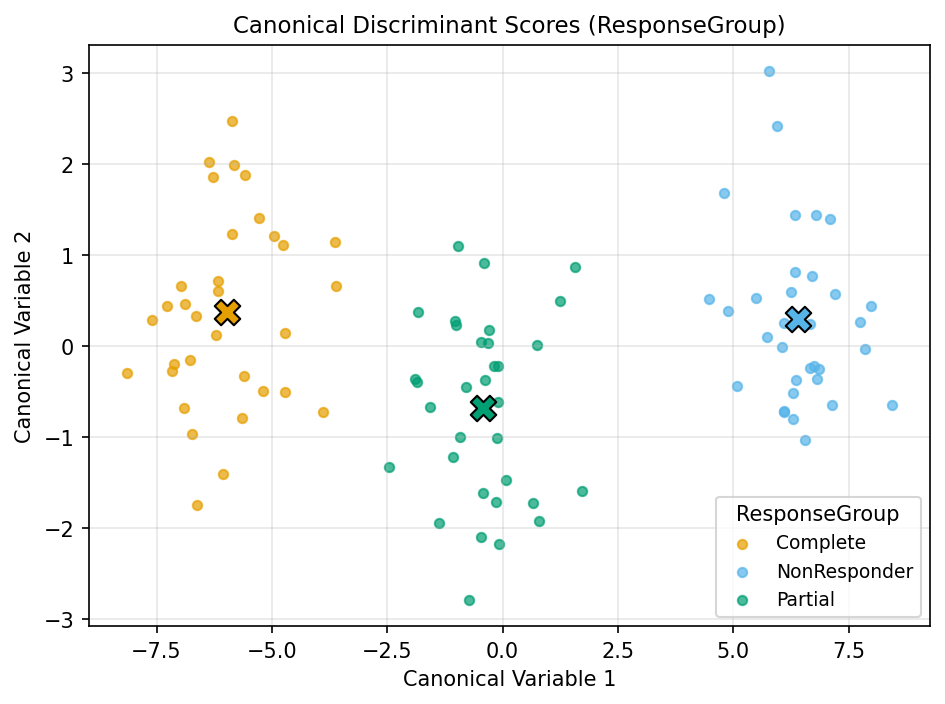

In [3]:
proc hpcandisc data=work.pkpd ncan=2
               simple anova distance stdmean;
  class ResponseGroup;
  var TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
run;

## Step 4 — Score patients onto the canonical axes

The `OUT=` dataset attaches each patient's canonical scores (`Can1`, `Can2`) to the data. We rename the canonical prefix with `PREFIX=CanAxis` for clarity and carry `PatientID` and `ResponseGroup` through with an `ID` statement so the scored dataset is immediately usable for a 2-D separation plot or for flagging patients whose canonical position disagrees with their assigned phenotype.


PatientID  ResponseGroup   CANAXIS1   CANAXIS2
---------  -------------  ---------  ---------
        1  NonResponder    6.053775  -0.003541
        2  Partial         0.790931  -1.925165
        3  Complete        -6.22034   0.127655
        4  NonResponder    6.659439   -0.23629
        5  Partial        -1.836782   0.377423
        6  Complete       -5.279015   1.406605
        7  NonResponder    7.091362   1.394368
        8  Partial        -0.328456   0.037976
        9  Complete       -6.724992  -0.959181

... 90 more observations (showing 9 of 99)



NOTE: PROC HPCANDISC
NOTE: PROC CANDISC data=work.pkpd ncan=Some(2) prefix=CanAxis

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 99
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   Complete: 33
NOTE:   NonResponder: 33
NOTE:   Partial: 33
NOTE: Canonical Correlations:
NOTE:   Can1: 0.981638
NOTE:   Can2: 0.436484
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       26.482174    0.981638            0.963613
NOTE:   Can2        0.235358    0.436484            0.190518
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.029455     88.81      10   184.0   0.0000
NOTE:   Pillai's Trace        1.154131     25.11      10   184.0   0.0000
NOTE:   Hotelling-Lawley     26.717532    327.07      10  

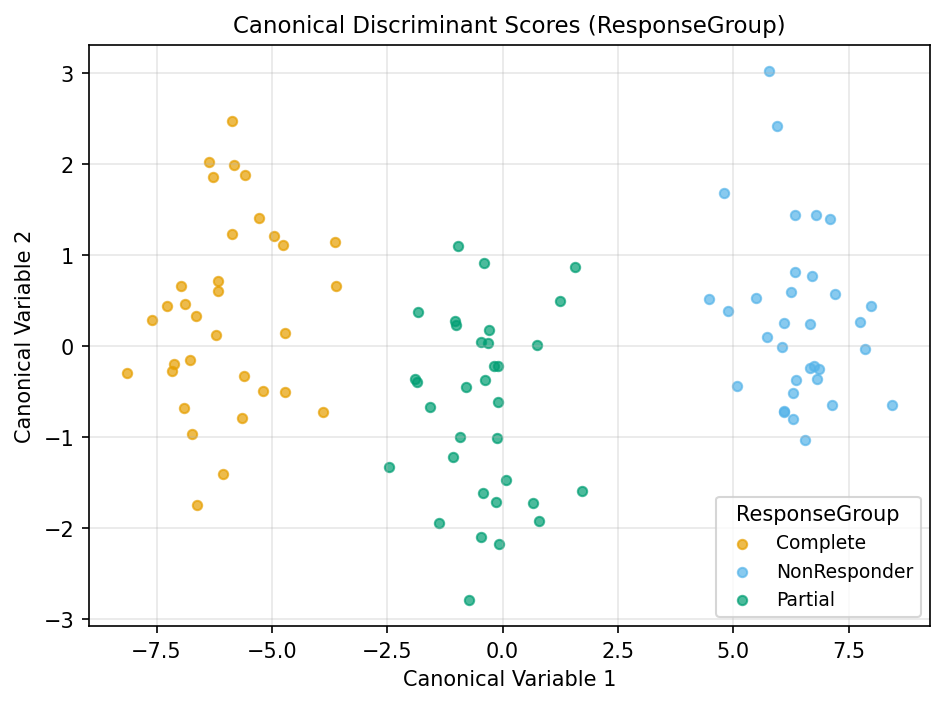

In [4]:
proc hpcandisc data=work.pkpd out=work.canscores
               ncan=2 prefix=CanAxis short;
  class ResponseGroup;
  var TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
  id PatientID ResponseGroup;
run;

proc print data=work.canscores(obs=9) noobs;
  var PatientID ResponseGroup CanAxis1 CanAxis2;
run;

## Step 5 — Mean canonical position per phenotype

Averaging the canonical scores within each response group gives the group **centroids** in canonical space. The spread of these centroids along `CanAxis1` versus `CanAxis2` shows, concretely, which axis does the separating work.

In [5]:
proc means data=work.canscores mean maxdec=3;
  class ResponseGroup;
  var CanAxis1 CanAxis2;
run;

                                                  The MEANS Procedure

                                              Analysis Variable : CanAxis1

                                   N
        ResponseGroup            Obs           Mean
        -------------------------------------------
        Complete                  33         -5.979
        NonResponder              33          6.411
        Partial                   33         -0.431
        -------------------------------------------

                                              Analysis Variable : CanAxis2

                                   N
        ResponseGroup            Obs           Mean
        -------------------------------------------
        Complete                  33          0.372
        NonResponder              33          0.302
        Partial                   33         -0.674
        -------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 6 — Persist the canonical model coefficients

The `OUTSTAT=` dataset is a `TYPE=CORR` table holding the class means, canonical correlations, canonical structure (correlations between each biomarker and each canonical axis), and the raw and standardized canonical coefficients. Saving it lets us apply the same canonical transformation to future patients without re-fitting, and lets us read off which biomarkers load most heavily on each axis.


  _TYPE_          _NAME_  TUMORSHRINKAGE  IL6_PGML  CTDNA_COPIES  DRUGAUC  QOLSCORE       CAN1      CAN2
--------  --------------  --------------  --------  ------------  -------  --------  ---------  --------
CANCORR                                .         .             .        .         .   0.981638  0.436484
STRUCTUR  TumorShrinkage               .         .             .        .         .  -0.534553  0.435375
STRUCTUR  IL6_pgml                     .         .             .        .         .   0.431265  0.151311
STRUCTUR  ctDNA_copies                 .         .             .        .         .   0.539255  0.711061
STRUCTUR  DrugAUC                      .         .             .        .         .  -0.431336   0.37645
STRUCTUR  QoLScore                     .         .             .        .         .  -0.363398   0.11153



NOTE: PROC HPCANDISC
NOTE: PROC CANDISC data=work.pkpd ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: ODS plot written: candisc_scores.spec.json
NOTE: PROC CANDISC: 99 observations, 5 variables
NOTE: PROC PRINT data=work.canstat

NOTE: PROC PRINT completed: 6 observations printed, 9 variables


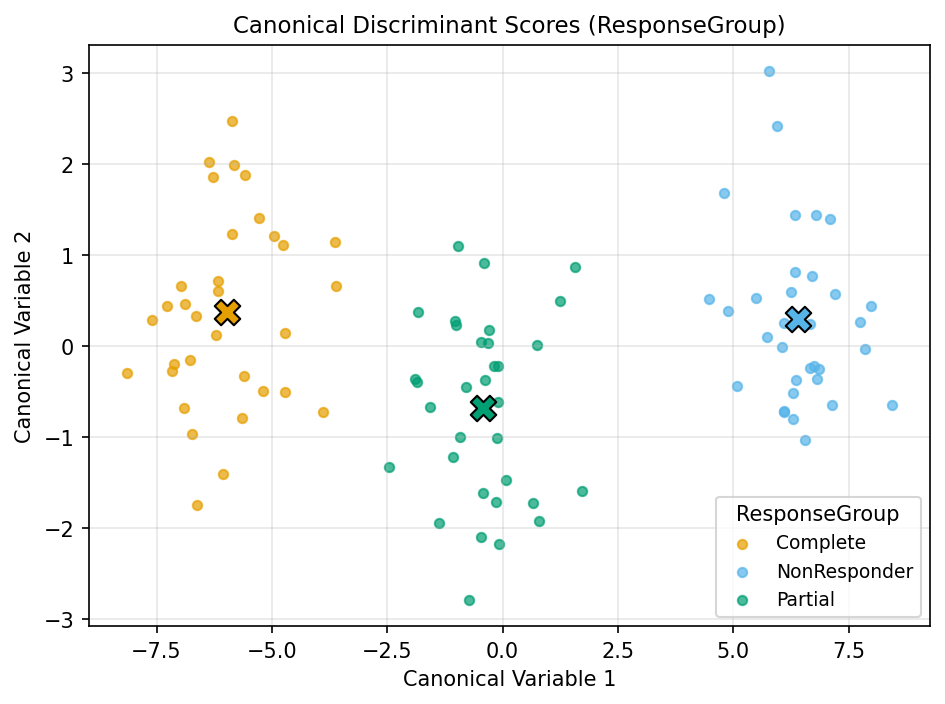

In [6]:
proc hpcandisc data=work.pkpd outstat=work.canstat
               ncan=2 noprint;
  class ResponseGroup;
  var TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
run;

proc print data=work.canstat noobs;
  where _TYPE_ in ("STRUCTUR", "CANCORR");
run;

## Interpreting the results

**Overall separation.** The multivariate tests (Wilks' Lambda = 0.0295, Pillai's Trace = 1.154, Hotelling-Lawley = 26.72) are all highly significant (p < 0.0001), confirming the three response phenotypes are strongly distinguishable on the five-biomarker panel taken together.

**Canonical axes.** The first canonical variable carries almost all of the discriminating power — its squared canonical correlation is 0.964 (canonical correlation 0.982), so it explains the overwhelming majority of between-group variation. The second axis is weaker (squared canonical correlation 0.191) but still significant: the sequential test that the remaining correlation is zero rejects at p = 0.0005. In practice, a single canonical score (`CanAxis1`) orders the phenotypes along a clean monotonic gradient — the group centroids fall at -5.98 (Complete), -0.43 (Partial), and +6.41 (NonResponder), so `CanAxis1` cleanly separates complete responders from non-responders with partial responders in between.

**Which biomarkers drive separation.** The univariate `ANOVA` F tests show every biomarker differs across groups (all F > 168, p < 0.0001), but the **canonical structure** (from the `OUTSTAT=` table) reveals the multivariate story: on `CanAxis1` ctDNA burden (0.539) and tumor shrinkage (-0.535) load most heavily — the dominant response gradient — while drug AUC (-0.431), IL-6 (0.431), and quality-of-life (-0.363) contribute progressively weaker signal. The squared Mahalanobis distances from the `DISTANCE` option quantify the gaps: complete and non-responders sit furthest apart (153.5), with partial responders intermediate (31.9 to Complete, 47.8 to NonResponder), matching clinical intuition.

**Practical use.** The scored `work.canscores` dataset places every patient on a two-dimensional separation map. Patients whose canonical position lands far from their assigned phenotype's centroid are candidates for adjudication review, and the saved `OUTSTAT=` coefficients let the trial team project newly enrolled patients onto the same axes for real-time response monitoring.